# Two-Sample Simulation Setup (for the individual report)
Importing libraries and initializing parameters. Note that in 2-sample mode, `n_subj` represents the total population (split 50/50).

In [1]:
import helper_functions as hf
import plotters as pl
import numpy as np
import importlib

importlib.reload(hf)
importlib.reload(pl)

n_runs = 20           # Number of simulation iterations
n_subj = 20           # Total subjects (Group 1: 10, Group 2: 10)
img_side_length = 64
smoothing_sigma = 1.5
alpha = 0.05
n_perm = 50          # Number of label-shuffling permutations per run
null_boundary = 1e-3


In [2]:
test_snrs = [0]
test_sigmas = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4, 4.5, 5]

sens_mat_2s, fwer_mat_2s = hf.run_2d_sweep(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=alpha,
    labels=True,        # 2-Sample Logic
    n_perm=n_perm,
    null_boundary=null_boundary
)

Starting 3D Sweep: 18 Sigmas x 1 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.1...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.25...
  > Processing Sigma = 1.5...
  > Processing Sigma = 1.75...
  > Processing Sigma = 2.0...
  > Processing Sigma = 2.25...
  > Processing Sigma = 2.5...
  > Processing Sigma = 2.75...
  > Processing Sigma = 3.0...
  > Processing Sigma = 3.5...
  > Processing Sigma = 4...
  > Processing Sigma = 4.5...
  > Processing Sigma = 5...
Sweep Complete.


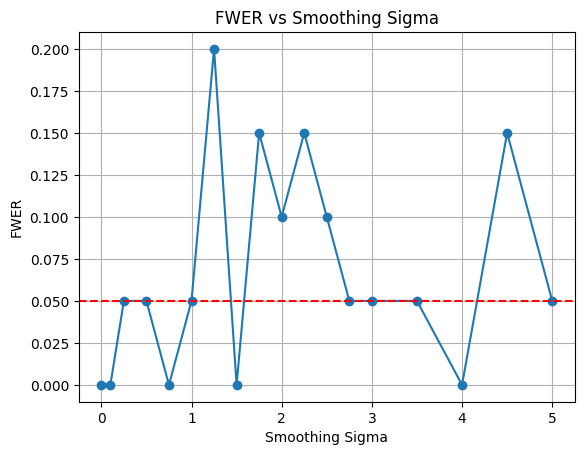

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# flatten fwer array
fwer = fwer_mat_2s.flatten()

# plot
plt.figure()
plt.plot(test_sigmas, fwer, marker='o')
plt.xlabel("Smoothing Sigma")
plt.ylabel("FWER")
plt.title("FWER vs Smoothing Sigma")
plt.grid(True)
plt.axhline(y=0.05, linestyle='--',color='r', label='Alpha = 0.05')
plt.show()

## 2D Parameter Sweep (SNR vs. Smoothing)
We sweep across various Signal-to-Noise Ratios and Smoothing levels. 
**Crucial:** We pass `labels=True` to simulate group differences and use label-permutation thresholding.

In [4]:
test_snrs = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]
test_sigmas = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]

sens_mat_2s, fwer_mat_2s = hf.run_2d_sweep(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=alpha,
    labels=True,        # 2-Sample Logic
    n_perm=n_perm,
    null_boundary=null_boundary
)

Starting 3D Sweep: 10 Sigmas x 10 SNRs
  > Processing Sigma = 0...
  > Processing Sigma = 0.25...
  > Processing Sigma = 0.5...
  > Processing Sigma = 0.75...
  > Processing Sigma = 1.0...
  > Processing Sigma = 1.5...
  > Processing Sigma = 2.0...
  > Processing Sigma = 3.0...
  > Processing Sigma = 4.0...
  > Processing Sigma = 5...
Sweep Complete.


## 3D Surface Results
Visualizing how the Two-Sample method performs under different noise and spatial correlation conditions.


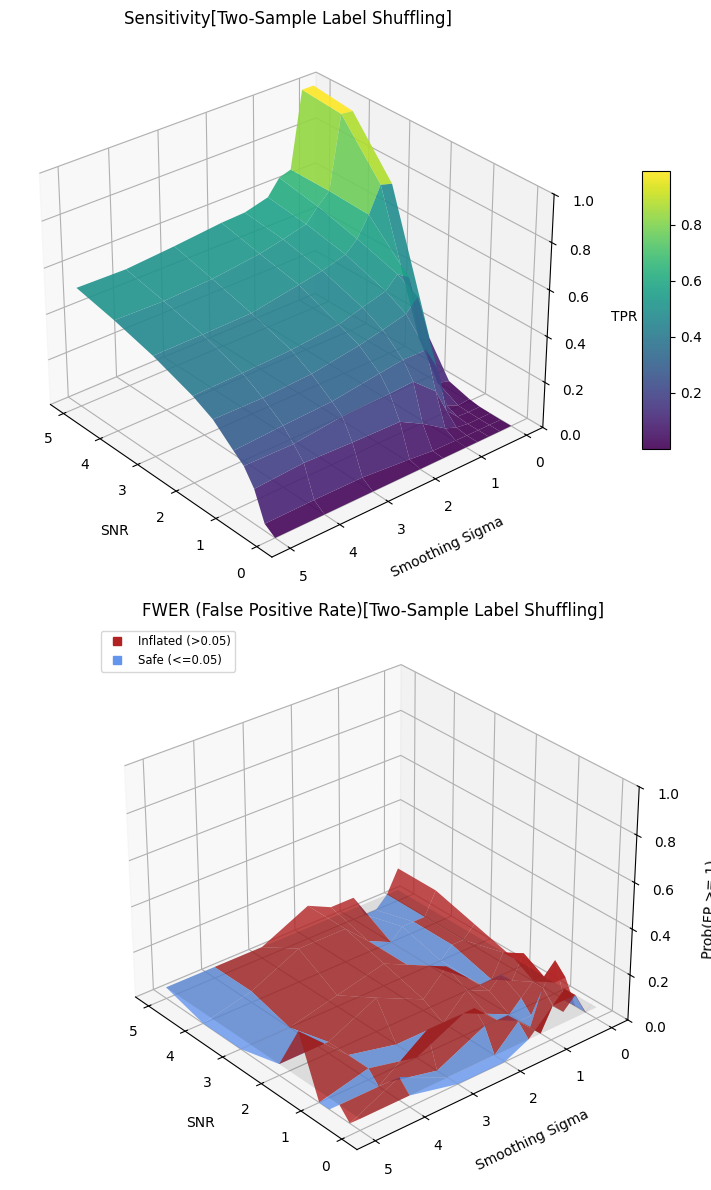

In [5]:
pl.plot_3d_surfaces(
    snrs=test_snrs,
    sigmas=test_sigmas,
    sens_matrix=sens_mat_2s,
    fwer_matrix=fwer_mat_2s,
    extra_title="[Two-Sample Label Shuffling]",
    elev=30, azim=140
)

## Sensitivity & FWER Analysis
Plotting sensitivity curves to see the impact of smoothing on the 2nd sample group comparison.

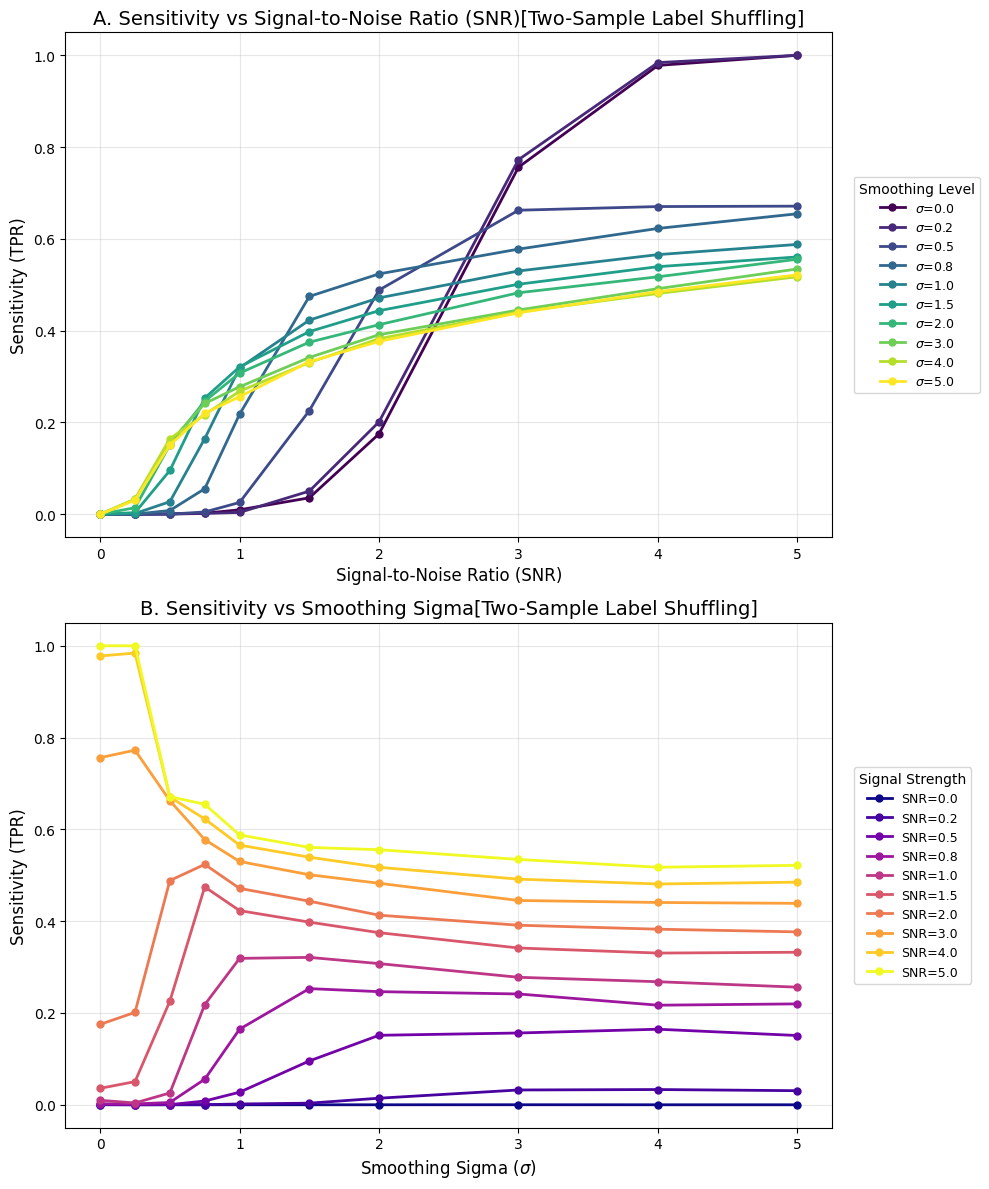

In [6]:
test_snrs = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]
test_sigmas = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]

# Plot Sensitivity vs SNR/Sigma
pl.plot_sensitivity_analysis(
    snrs=test_snrs,
    sigmas=test_sigmas,
    sens_matrix=sens_mat_2s,
    extra_title="[Two-Sample Label Shuffling]"
)



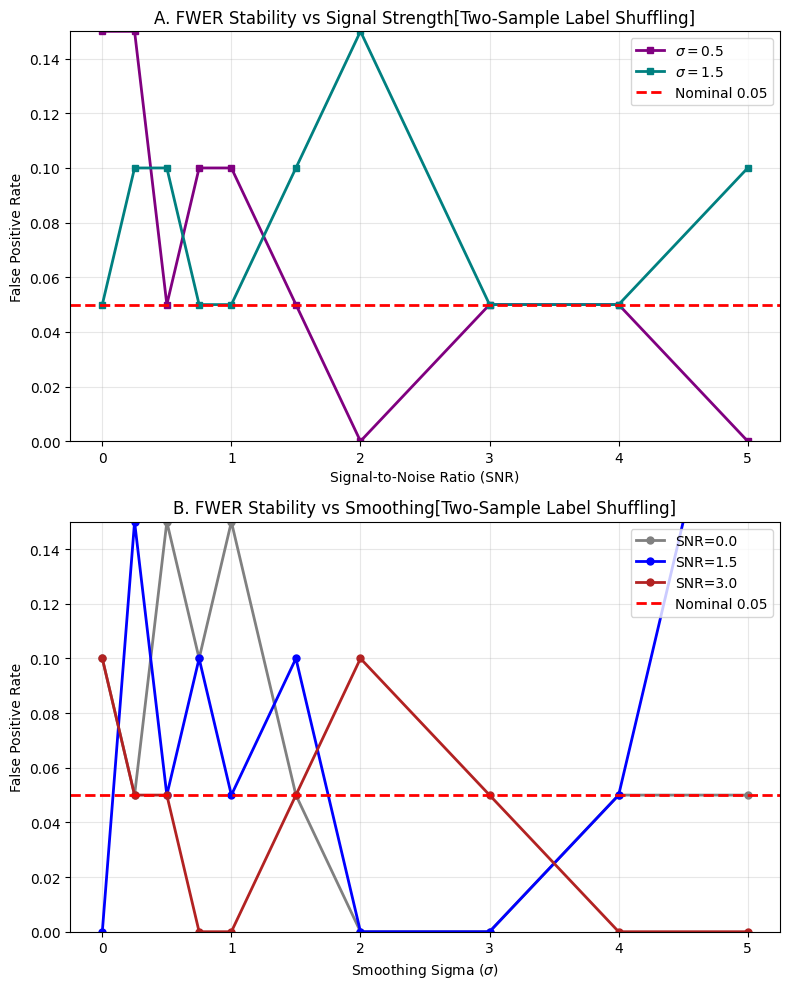

In [7]:
test_snrs = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]
test_sigmas = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5]

# Plot FWER Stability
pl.plot_fwer_stability(
    snrs=test_snrs,
    sigmas=test_sigmas,
    fwer_matrix=fwer_mat_2s,
    original_sigmas_list=np.array(test_sigmas),
    original_snrs_list=np.array(test_snrs),
    extra_title="[Two-Sample Label Shuffling]"
)
